<a href="https://colab.research.google.com/github/t-ashriya/AI4ALL-Fraud-Detection/blob/main/colab_notebook/%20FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Dataset

In [ ]:
import pandas as pd


path = "/content/drive/MyDrive/AI4All Team12D/Fraud_Detection/Datasets/fraudTrain.csv"


Alternative to load the datasets

In [ ]:
import kagglehub, os
path = kagglehub.dataset_download("kartik2112/fraud-detection")
df = pd.read_csv(os.path.join(path, "fraudTrain.csv"))

Using Colab cache for faster access to the 'fraud-detection' dataset.


In [ ]:
df.head(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,40.3750,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
6,6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,...,37.9931,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,38.8432,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
8,8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,...,40.3359,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0
9,9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0


### Creating a copy of original dataset

In [ ]:
#creating a copy of original dataset
df_clean = df.copy()

CHECKING INVALID VALUES

In [ ]:
import pandas as pd
import numpy as np


blank_rows = df[df.isna().all(axis=1)]
print("Fully blank rows:", blank_rows.index.tolist())



df = df[~df.isna().all(axis=1)]



print("=== Negative/zero amounts ===")
print((df['amt'] <= 0).sum())


print("=== Invalid is_fraud ===")
print(df[~df['is_fraud'].isin([0, 1])])


print("=== Invalid gender ===")
print(df[~df['gender'].isin(['M', 'F'])])


print("=== Invalid lat ===")
print((df['lat'].notna() & ~df['lat'].between(-90, 90)).sum())


print("=== Invalid long ===")
print((df['long'].notna() & ~df['long'].between(-180, 180)).sum())


print("=== Negative city_pop ===")
print((df['city_pop'] < 0).sum())


print("=== Duplicate trans_num ===")
print(df['trans_num'].duplicated().sum())







Fully blank rows: []
=== Negative/zero amounts ===
0
=== Invalid is_fraud ===
Empty DataFrame
Columns: [Unnamed: 0, trans_date_trans_time, cc_num, merchant, category, amt, first, last, gender, street, city, state, zip, lat, long, city_pop, job, dob, trans_num, unix_time, merch_lat, merch_long, is_fraud]
Index: []

[0 rows x 23 columns]
=== Invalid gender ===
Empty DataFrame
Columns: [Unnamed: 0, trans_date_trans_time, cc_num, merchant, category, amt, first, last, gender, street, city, state, zip, lat, long, city_pop, job, dob, trans_num, unix_time, merch_lat, merch_long, is_fraud]
Index: []

[0 rows x 23 columns]
=== Invalid lat ===
0
=== Invalid long ===
0
=== Negative city_pop ===
0
=== Duplicate trans_num ===
0


In [ ]:
#Checking for null values per column

print(df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


Creating Dictionaries for deployment

In [ ]:
# Card average amount and timestamps dictionary
import joblib

card_database = {}

for cc_num, group in df_clean.groupby("cc_num"):

    group = group.sort_values("unix_time")

    card_database[cc_num] = {
        "avg_amt": group["amt"].mean(),
        "timestamps": group["unix_time"].tolist()
    }

joblib.dump(card_database, "card_database.pkl")

['card_database.pkl']

In [ ]:
#Category -> count dictionary
category_dict = (
    df_clean["category"]
    .value_counts()
    .to_dict()
)

joblib.dump(category_dict, "category_dict.pkl")

['category_dict.pkl']

### Dropping unnecessary Columns

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [ ]:
import pandas as pd
#df = pd.read_csv(path)
df_clean = df.copy()

# dropping unnecessary columns
cols_to_drop = [
    'Unnamed: 0',
    'first',
    'last',
    'street',
    'trans_num'
]

df_clean.drop(columns=cols_to_drop, inplace=True)
print(df_clean.shape)

(1296675, 18)


In [ ]:
print(df_clean.columns.tolist())

['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


### Searching Duplicates If Found

In [ ]:
# Searching for duplicates and removing them if found
total_duplicates = df_clean.duplicated().sum()
print(f"Total duplicates: {total_duplicates}")
print(df_clean.duplicated())

# Display all duplicate rows (excluding the first occurrence)
duplicate_rows = df_clean[df_clean.duplicated()]
print(duplicate_rows)




Total duplicates: 0
0          False
1          False
2          False
3          False
4          False
           ...  
1296670    False
1296671    False
1296672    False
1296673    False
1296674    False
Length: 1296675, dtype: bool
Empty DataFrame
Columns: [trans_date_trans_time, cc_num, merchant, category, amt, gender, city, state, zip, lat, long, city_pop, job, dob, unix_time, merch_lat, merch_long, is_fraud]
Index: []


# Feature Engineering

'dob' Column

In [ ]:
df_clean['dob'].nunique()

968

In [ ]:
df_clean['dob'].value_counts().head(10)

,count
dob,
1977-03-23,5636
1981-08-29,4636
1988-09-15,4623
1955-05-06,3661
1983-07-25,3123
1995-07-12,3123
1987-10-28,3119
1984-06-03,3117
1999-03-05,3113


In [ ]:
#convert dob to age, then replace the column
df_clean['dob'] = pd.to_datetime(df_clean['dob'])
today = pd.to_datetime('today')
df_clean['dob'] = (today - df_clean['dob']).dt.days // 365
df_clean = df_clean.rename(columns={'dob': 'age'})

In [ ]:
df_clean['age'].nunique()

81

In [ ]:
df_clean['age'].unique()[:20]

array([38, 48, 64, 59, 40, 65, 33, 79, 85, 52, 36, 60, 37, 80, 61, 74, 88,
       45, 54, 81])

In [ ]:
df_clean['age'].head(10)

,age
0,38
1,48
2,64
3,59
4,40
5,65
6,33
7,79
8,85
9,52


'Gender' Column

In [ ]:
df_clean['gender'].nunique()

2

In [ ]:
df_clean['gender'].value_counts()

,count
gender,
F,709863
M,586812


In [ ]:
#replace values for column gender with 0/1
df_clean['gender'] = df_clean['gender'].map({'M': 1, 'F': 0})

In [ ]:
df_clean['gender'].nunique()

2

In [ ]:
df_clean['gender'].unique()[:20]

array([0, 1])

In [ ]:
df_clean['gender'].head(10)

,gender
0,0
1,0
2,1
3,1
4,1
5,0
6,0
7,1
8,0
9,0


'Category' Column

In [ ]:
df_clean['category'].nunique()

14

In [ ]:
df_clean['category'].value_counts().head(10)

,count
category,
gas_transport,131659
grocery_pos,123638
home,123115
shopping_pos,116672
kids_pets,113035
shopping_net,97543
entertainment,94014
food_dining,91461
personal_care,90758


In [ ]:
#replace values for column category with it's count
category_counts = df_clean['category'].value_counts()

df_clean['category'] = df_clean['category'].map(category_counts)

In [ ]:
df_clean['category'].nunique()

14

In [ ]:
df_clean['category'].unique()[:20]

array([ 63287, 123638,  94014, 131659,  79655,  45452,  97543, 116672,
        91461,  90758,  85879,  40507, 113035, 123115])

In [ ]:
df_clean['category'].head(10)

,category
0,63287
1,123638
2,94014
3,131659
4,79655
5,131659
6,45452
7,131659
8,79655
9,123638


'merchant' Column

In [ ]:
df_clean['merchant'].nunique()

693

In [ ]:
df_clean['merchant'].value_counts().head(10)

,count
merchant,
fraud_Kilback LLC,4403
fraud_Cormier LLC,3649
fraud_Schumm PLC,3634
fraud_Kuhn LLC,3510
fraud_Boyer PLC,3493
fraud_Dickinson Ltd,3434
fraud_Cummerata-Jones,2736
fraud_Kutch LLC,2734
"fraud_Olson, Becker and Koch",2723


In [ ]:
#replace values for column merchant with it's count
merchant_counts = df_clean['merchant'].value_counts()

df_clean['merchant'] = df_clean['merchant'].map(merchant_counts)

In [ ]:
df_clean['merchant'].nunique()

553

In [ ]:
df_clean['merchant'].unique()[:20]

array([1267, 2503, 1895, 2613, 1592, 2721,  906, 2675, 1659, 2467, 2489,
       1838, 2492, 2452, 2365, 1950, 1332, 2351, 1861, 2399])

In [ ]:
df_clean['merchant'].head(10)

,merchant
0,1267
1,2503
2,1895
3,2613
4,1592
5,2721
6,906
7,2675
8,1659
9,2467


'job' column

In [ ]:
df_clean['job'].nunique()

494

In [ ]:
df_clean['job'].value_counts().head(10)

,count
job,
Film/video editor,9779
Exhibition designer,9199
Naval architect,8684
"Surveyor, land/geomatics",8680
Materials engineer,8270
"Designer, ceramics/pottery",8225
Systems developer,7700
IT trainer,7679
Financial adviser,7659


In [ ]:
#replace values for column 'jobs' with it's count
job_counts = df_clean['job'].value_counts()

df_clean['job'] = df_clean['job'].map(job_counts)



In [ ]:
df_clean['job'].nunique()

381

In [ ]:
df_clean['job'].head(10)

,job
0,3545
1,5099
2,511
3,2530
4,2017
5,2098
6,3101
7,1053
8,2024
9,1042


'city pop' column

In [ ]:
df_clean['city_pop'].head(10)

,city_pop
0,3495
1,149
2,4154
3,1939
4,99
5,2158
6,2691
7,6018
8,1472
9,151785


In [ ]:
print(df_clean['city_pop'].nunique())
df_clean['city_pop'].value_counts().head(10)

879


,count
city_pop,
606,5496
1595797,5130
1312922,5075
1766,4574
241,4533
2906700,4168
276002,4155
302,4147
910148,4073


'zip' column

In [ ]:
df_clean['zip'].head()

,zip
0,28654
1,99160
2,83252
3,59632
4,24433


In [ ]:
df_clean['zip'].value_counts().head(10)

,count
zip,
73754,3646
34112,3613
48088,3597
82514,3527
49628,3123
15484,3123
85173,3119
29819,3117
38761,3113


'lat', 'long', 'merch_lat', 'merch_long' column

In [ ]:
from math import radians, sin, cos, sqrt, asin

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius

    # Convert degrees to radians
    phi1 = radians(lat1)
    phi2 = radians(lat2)

    delta_phi = radians(lat2 - lat1)
    delta_lambda = radians(lon2 - lon1)

    # Use Haversine formula to calculate distance between merchant and customer
    a = (sin(delta_phi / 2) ** 2 +cos(phi1) * cos(phi2) *sin(delta_lambda / 2) ** 2)

    distance = 2 * R * asin(sqrt(a))

    return distance




In [ ]:
df_clean['distance_km'] = df_clean.apply(
    lambda transaction: haversine(
        transaction['lat'],
        transaction['long'],
        transaction['merch_lat'],
        transaction['merch_long']
    ),
    axis=1
).round(2)

In [ ]:
df_clean['distance_km'].head(10)

,distance_km
0,78.60
1,30.21
2,108.21
3,95.67
4,77.56
5,85.92
6,118.12
7,12.77
8,25.27
9,74.08


'city' and 'state' column

In [ ]:
#City

# Create city -> population mapping
city_to_pop = (
    df_clean[['city', 'city_pop']]
    .drop_duplicates()
    .set_index('city')['city_pop']
    .to_dict()
)

# Replace city names with population values
df_clean['city'] = df_clean['city'].map(city_to_pop)
# State
df_clean['state'] = df_clean['state'].str.strip().str.upper()
df_clean['state'].fillna('Unknown', inplace=True)

encoded_location = pd.get_dummies(df_clean[['state']], drop_first=True)
df_clean = pd.concat([df_clean, encoded_location], axis=1)

print("State cleaned and encoded")
print(df_clean.shape)

/tmp/ipykernel_3225/3047695077.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['state'].fillna('Unknown', inplace=True)


State cleaned and encoded
(1296675, 69)


In [ ]:
print(encoded_location.columns.tolist())

['state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI', 'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA', 'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY']


In [ ]:
print(df_clean.columns)

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'age', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'distance_km', 'state_AL', 'state_AR', 'state_AZ', 'state_CA',
       'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA',
       'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS',
       'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI',
       'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND',
       'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
       'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI', 'state_SC',
       'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA', 'state_VT',
       'state_WA', 'state_WI', 'state_WV', 'state_WY'],
      dtype='object')


'trans_date_time' column


In [ ]:

df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])

df_clean['hour'] = df_clean['trans_date_trans_time'].dt.hour
df_clean['day_of_week'] = df_clean['trans_date_trans_time'].dt.dayofweek
df_clean['month'] = df_clean['trans_date_trans_time'].dt.month
df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)


Visualizing fraud at different times of the day.


In [ ]:
df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
df_clean['hour'] = df_clean['trans_date_trans_time'].dt.hour

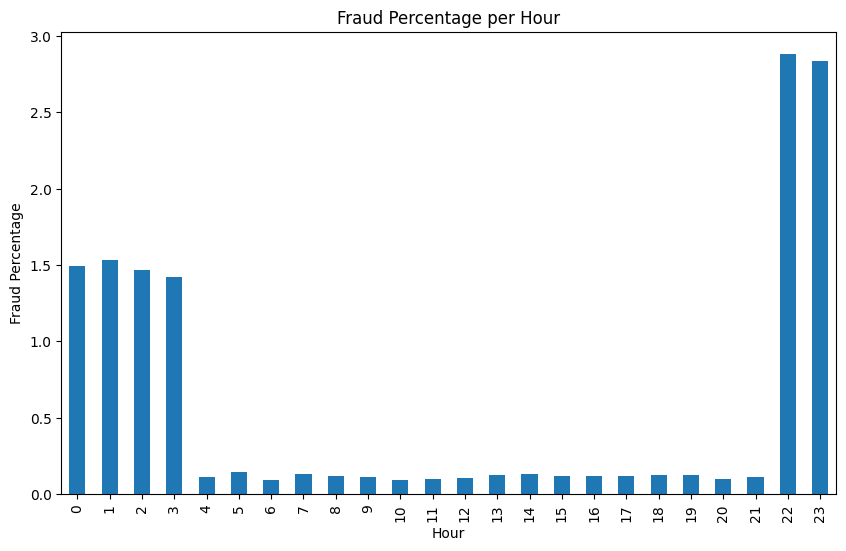

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 6))
hourly = df_clean.groupby("hour")['is_fraud'].mean() * 100 #fraud percentage per hour
hourly.plot(kind='bar')
plt.title('Fraud Percentage per Hour')
plt.xlabel('Hour')
plt.ylabel('Fraud Percentage')
plt.show()

More data extraction from trans_date_trans_time and Cyclical enconding.

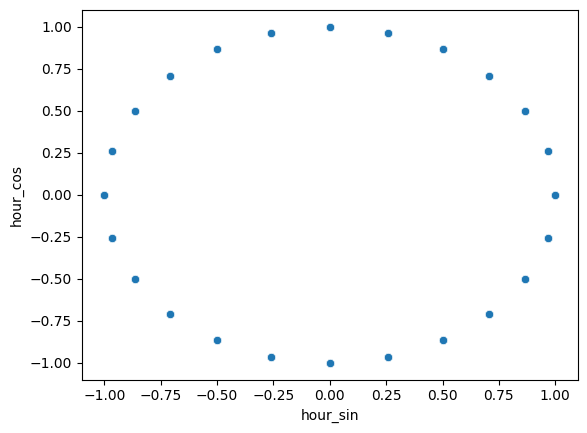

In [ ]:
import numpy as np
import seaborn as sns
#time of the day
df_clean['hour_sin']  = np.sin(2 * np.pi * df_clean['hour'] / 24) #this and the next line ensures that the model knows that hour 23 and hour 0 are 1hour appart.
df_clean['hour_cos']  = np.cos(2 * np.pi * df_clean['hour'] / 24)
df_clean['is_night']  = df_clean['hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)
#the sin and cosine of the day of the week will be added if needed
sns.scatterplot(x=df_clean['hour_sin'],y=df_clean['hour_cos'])
plt.show()

Feature engineering relateing cc_num, trans_date_trans_time, and unix time columns.

"amt" column

In [ ]:
bins = [0, 50, 200, 500, 1000, float("inf")]
labels = [0, 1, 2, 3, 4]

df_clean["amt_bin"] = pd.cut(
    df_clean["amt"],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)



Visualization of binding

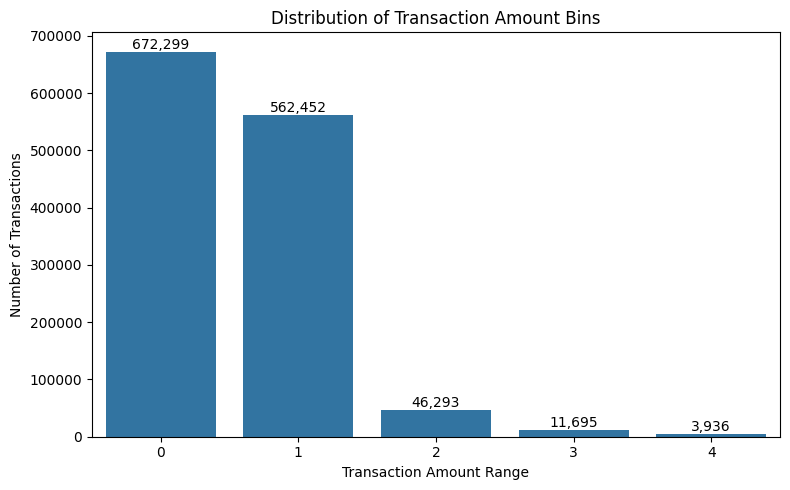

In [ ]:
counts = df_clean["amt_bin"].value_counts().sort_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=[labels[i] for i in counts.index],
    y=counts.values
)

# Add counts above bars
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.title("Distribution of Transaction Amount Bins")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [ ]:
amt_dummies = pd.get_dummies(
    df_clean["amt_bin"],
    prefix="amt_bin"
)

df_clean = pd.concat([df_clean, amt_dummies], axis=1)

# Optional: remove the original amt_bin column
df_clean.drop(columns=["amt_bin"], inplace=True)

In [ ]:
df_clean.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job',
       'age', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud',
       'distance_km', 'state_AL', 'state_AR', 'state_AZ', 'state_CA',
       'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA',
       'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS',
       'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI',
       'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND',
       'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
       'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI', 'state_SC',
       'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA', 'state_VT',
       'state_WA', 'state_WI', 'state_WV', 'state_WY', 'hour', 'day_of_week',
       'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_night', 'amt_bin_0',
      

In [ ]:
columns_to_drop = [
    'trans_date_trans_time',
    'cc_num',
    'lat',
    'long',
    'merch_lat',
    'merch_long',
    'state',
    'city_pop',
    'amt'

]


In [ ]:
df_clean.drop(
    columns=columns_to_drop,
    inplace=True
)

print(df_clean.columns)

Index(['merchant', 'category', 'gender', 'city', 'zip', 'job', 'age',
       'unix_time', 'is_fraud', 'distance_km', 'state_AL', 'state_AR',
       'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE',
       'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL',
       'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD',
       'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT',
       'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM',
       'state_NV', 'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA',
       'state_RI', 'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT',
       'state_VA', 'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY',
       'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'is_night', 'amt_bin_0', 'amt_bin_1', 'amt_bin_2', 'amt_bin_3',
       'amt_bin_4'],
      dtype='object')


In [ ]:
df_clean.head(10)

,merchant,category,gender,city,zip,job,age,unix_time,is_fraud,distance_km,...,month,is_weekend,hour_sin,hour_cos,is_night,amt_bin_0,amt_bin_1,amt_bin_2,amt_bin_3,amt_bin_4
0,1267,63287,0,3495,28654,3545,38,1325376018,0,78.60,...,1,0,0.0,1.0,1,True,False,False,False,False
1,2503,123638,0,743,99160,5099,48,1325376044,0,30.21,...,1,0,0.0,1.0,1,False,True,False,False,False
2,1895,94014,1,4154,83252,511,64,1325376051,0,108.21,...,1,0,0.0,1.0,1,False,False,True,False,False
3,2613,131659,1,1939,59632,2530,59,1325376076,0,95.67,...,1,0,0.0,1.0,1,True,False,False,False,False
4,1592,79655,1,99,24433,2017,40,1325376186,0,77.56,...,1,0,0.0,1.0,1,True,False,False,False,False
5,2721,131659,0,2158,18917,2098,65,1325376248,0,85.92,...,1,0,0.0,1.0,1,False,True,False,False,False
6,906,45452,0,2691,67851,3101,33,1325376282,0,118.12,...,1,0,0.0,1.0,1,True,False,False,False,False
7,2675,131659,1,6018,22824,1053,79,1325376308,0,12.77,...,1,0,0.0,1.0,1,False,True,False,False,False
8,1659,79655,0,1472,15665,2024,85,1325376318,0,25.27,...,1,0,0.0,1.0,1,True,False,False,False,False
9,2467,123638,0,1146,37040,1042,52,1325376361,0,74.08,...,1,0,0.0,1.0,1,False,True,False,False,False


# Train and Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# defining label and features
X = df_clean.drop(columns='is_fraud')
y = df_clean['is_fraud']


#Create Training and Test Data Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#Balancing the Data

### Checking imbalance on the entire dataset

In [ ]:
df_clean['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


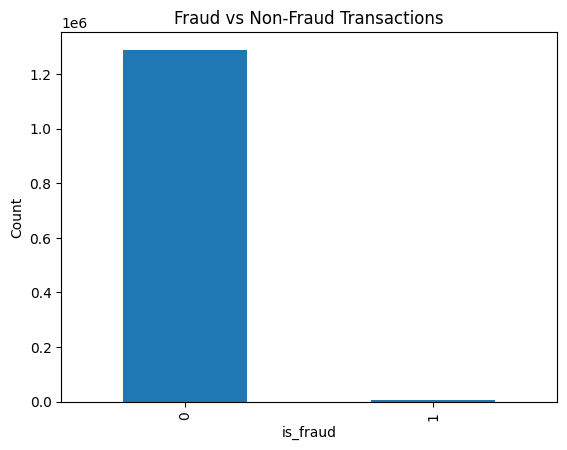

In [ ]:
import matplotlib.pyplot as plt

df_clean['is_fraud'].value_counts().plot(kind='bar')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.show()


### Checking imbalance in training and testing sets each after splitting

In [ ]:
#check for training label counts
print(pd.Series(y_train).value_counts())

train_counts = y_train.value_counts()

imbalance_ratio = train_counts[0] / train_counts[1]

print(f"\n Training imbalance ratio: {imbalance_ratio:.2f}:1")

is_fraud
0    1031335
1       6005
Name: count, dtype: int64

 Training imbalance ratio: 171.75:1


In [ ]:
#check for testing label counts
print(pd.Series(y_test).value_counts())

print(f"\n Testing imbalance ratio: {imbalance_ratio:.2f}:1")

is_fraud
0    257834
1      1501
Name: count, dtype: int64

 Testing imbalance ratio: 171.75:1


In [ ]:
#Balance Data Using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.30, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


In [ ]:
#Check for tain label counts after SMOTE
print(y_train_smote.value_counts())

is_fraud
0    1031335
1     309400
Name: count, dtype: int64


In [ ]:
#Imbalance ratio after SMOTE
ratio = y_train_smote.value_counts()[0] / y_train_smote.value_counts()[1]
print(f"SMOTE ratio: {ratio:.2f}:1")

SMOTE ratio: 3.33:1


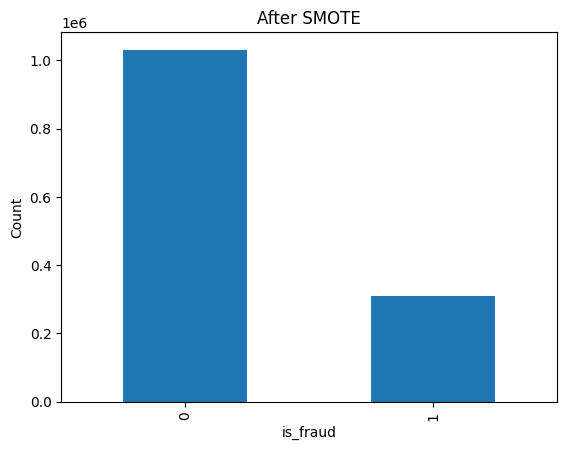

In [ ]:
import matplotlib.pyplot as plt

y_train_smote.value_counts().plot(kind='bar')

plt.title("After SMOTE")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.show()

# Model Training

In [ ]:
X_train_smote.columns


Index(['merchant', 'category', 'gender', 'city', 'zip', 'job', 'age',
       'unix_time', 'distance_km', 'state_AL', 'state_AR', 'state_AZ',
       'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL',
       'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN',
       'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME',
       'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC',
       'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
       'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI',
       'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA',
       'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY', 'hour',
       'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'is_night', 'amt_bin_0', 'amt_bin_1', 'amt_bin_2', 'amt_bin_3',
       'amt_bin_4'],
      dtype='object')

## **Logistic Regression**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Columns to scale
# I scaled because some of the values were too big and might end up confusing the model.

scale_cols = [
    "distance_km",
]

#Scale numerical features

scaler = StandardScaler()

X_train_smote[scale_cols] = scaler.fit_transform(X_train_smote[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Manual Feature Selection
# these features were selected with the help of recursive feature selection, and manual adjustment.

selected_features = [
    'distance_km',
    'hour_sin',
    'hour_cos',
    'merchant',
    'is_night',
    'amt_bin_0', 'amt_bin_1', 'amt_bin_2', 'amt_bin_3',
       'amt_bin_4'
]
# I ended up using everything because the precision was a little off.

# Keep only the selected features
X_train_smote_lr = X_train_smote[selected_features]
X_test_lr = X_test[selected_features]

print("Selected Features:")
print(X_train_smote.columns)

# Initialize Logistic Regression

log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

log_reg_model.fit(X_train_smote_lr, y_train_smote)

print("Logistic Regression Model Trained")

# Make predictions

y_pred = log_reg_model.predict(X_test_lr)

# Make probability predictions

y_prob = log_reg_model.predict_proba(X_test_lr)[:,1]

# Set classification threshold

threshold = 0.75

y_pred = (y_prob >= threshold).astype(int)

Selected Features:
Index(['merchant', 'category', 'gender', 'city', 'zip', 'job', 'age',
       'unix_time', 'distance_km', 'state_AL', 'state_AR', 'state_AZ',
       'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL',
       'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN',
       'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME',
       'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC',
       'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
       'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI',
       'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA',
       'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY', 'hour',
       'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos',
       'is_night', 'amt_bin_0', 'amt_bin_1', 'amt_bin_2', 'amt_bin_3',
       'amt_bin_4'],
      dtype='object')
Logistic Regression Model Tra

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Calculating evaluation matrix for Logistic regression model

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*45)
print(" Logistic Regression Evaluation Metrics")
print("="*45)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-Score : {f1:.2f}")
print(f"ROC-AUC  : {roc_auc:.2f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))


 Logistic Regression Evaluation Metrics
Accuracy : 0.99
Precision: 0.35
Recall   : 0.61
F1-Score : 0.45
ROC-AUC  : 0.95

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    257834
           1       0.35      0.61      0.45      1501

    accuracy                           0.99    259335
   macro avg       0.68      0.80      0.72    259335
weighted avg       0.99      0.99      0.99    259335



Confusion matrix report

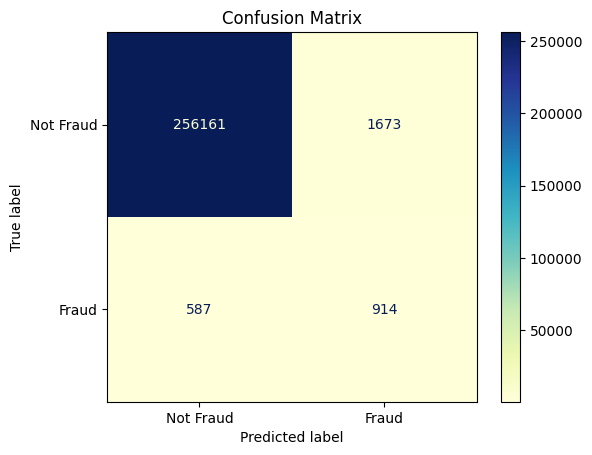

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap="YlGnBu",
    display_labels=["Not Fraud", "Fraud"]
)

plt.title("Confusion Matrix")
plt.show()

Perfromance Curves for Logistic regression model

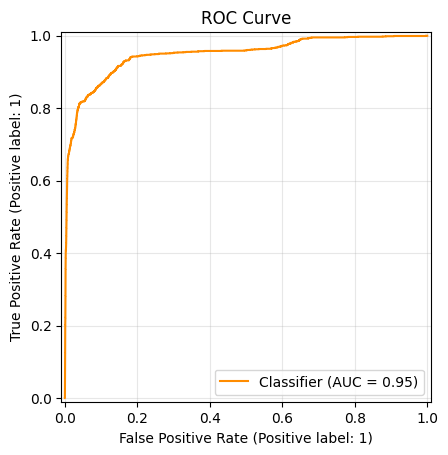

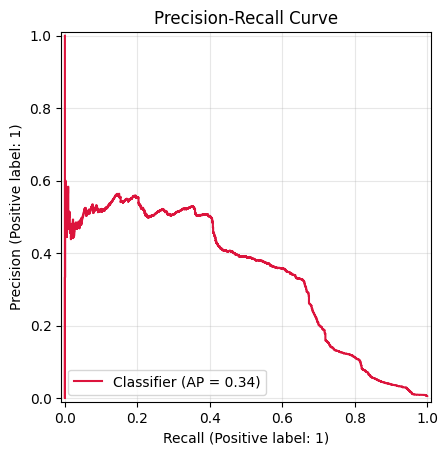

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    color="darkorange"
)

plt.title("ROC Curve")
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob,
    color="crimson"
)

plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.show()

Performance matrix chart

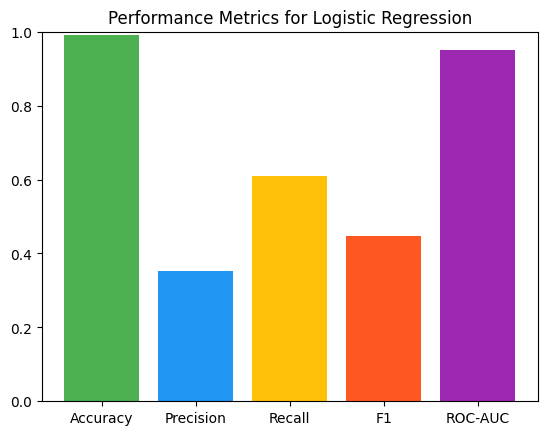

In [ ]:

plt.bar(
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    [accuracy, precision, recall, f1, roc_auc],
    color=["#4CAF50", "#2196F3", "#FFC107", "#FF5722", "#9C27B0"]
)

plt.ylim(0, 1)
plt.title("Performance Metrics for Logistic Regression")
plt.show()

## **Random Forest**

========Random Forest Model Trained========


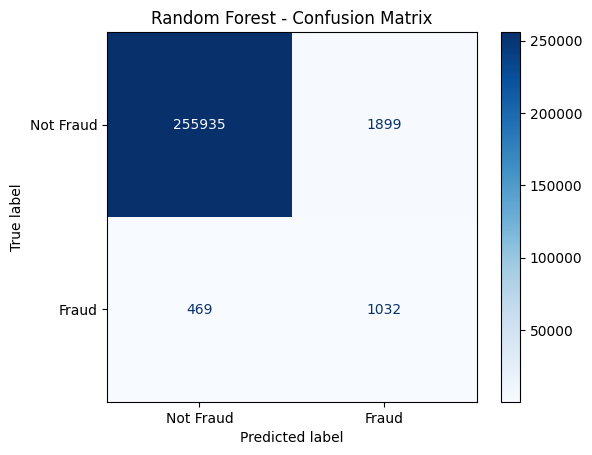

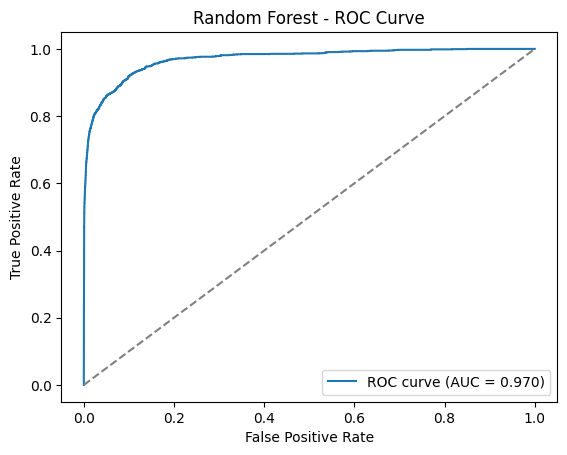

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=10
)

# Train on the SMOTE-balanced training data
random_forest_model.fit(X_train_smote, y_train_smote)

# Test on the REAL, untouched test set (created before SMOTE, back in the earlier cell)
y_pred = random_forest_model.predict(X_test)

# Probabilities
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("========Random Forest Model Trained========")
import matplotlib.pyplot as plt

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
threshold = 0.7
y_pred_adjusted = (y_prob_rf >= threshold).astype(int)

In [ ]:
# Calculate evaluation metrics

accuracy_random_forest = accuracy_score(
    y_test,
    y_pred_adjusted
)

precision_random_forest = precision_score(
    y_test,
    y_pred_adjusted,
    zero_division=0
)

recall_random_forest = recall_score(
    y_test,
    y_pred_adjusted,
    zero_division=0
)

f1_random_forest = f1_score(
    y_test,
    y_pred_adjusted,
    zero_division=0
)

roc_auc_random_forest = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest Evaluation Results")
print("-----------------------------")
print(f"Accuracy:  {accuracy_random_forest:.2f}")
print(f"Precision: {precision_random_forest:.2f}")
print(f"Recall:    {recall_random_forest:.2f}")
print(f"F1 Score:  {f1_random_forest:.2f}")
print(f"ROC-AUC: {roc_auc_random_forest:.2f}")

Random Forest Evaluation Results
-----------------------------
Accuracy:  1.00
Precision: 0.58
Recall:    0.57
F1 Score:  0.58
ROC-AUC: 0.97


Confusion Matrix For Random Forest

[[257199    635]
 [   639    862]]


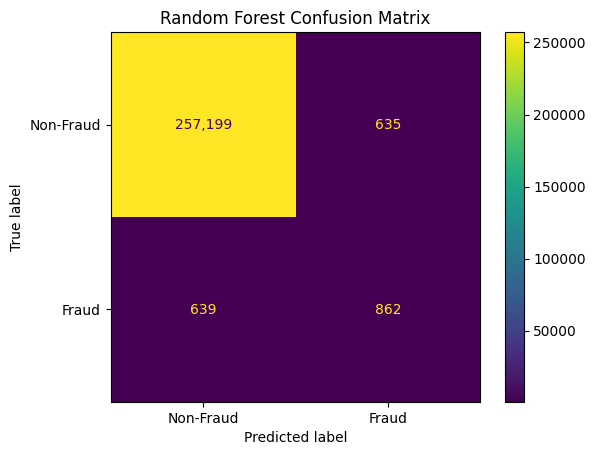

In [ ]:
cm_random_forest = confusion_matrix(
    y_test,
    y_pred_adjusted
)

print(cm_random_forest)

# Display confusion matrix

display_random_forest = ConfusionMatrixDisplay(
    confusion_matrix=cm_random_forest,
    display_labels=['Non-Fraud', 'Fraud']
)

display_random_forest.plot(
    values_format=',d'
)

plt.title('Random Forest Confusion Matrix')
plt.show()

Performance matrix for Random forest

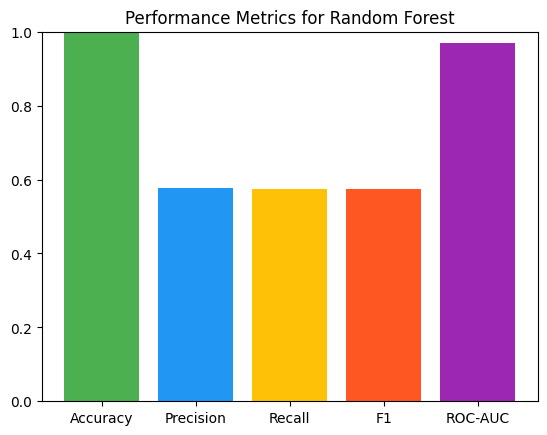

In [ ]:
plt.bar(
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    [accuracy_random_forest,precision_random_forest,recall_random_forest,f1_random_forest, roc_auc_random_forest],
    color=["#4CAF50", "#2196F3", "#FFC107", "#FF5722", "#9C27B0"]
)

plt.ylim(0, 1)
plt.title("Performance Metrics for Random Forest")
plt.show()

SHAP Analysis for Random Forest

In [ ]:
#Performing SHAP Analysis

#This section was deleted because the code had issues. however, prior to our presentation, the SHAP analysis was completed and successfull. We can always bring back the code if requested.

## **XG Boost**

In [ ]:
#Install XG Boost
!pip install xgboost -q

In [ ]:
#import  XGBoost and metrics/hyperparameters
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    make_scorer
)

import matplotlib.pyplot as plt

In [ ]:
#Create base XGBoost model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

#Parameters for Grid Search

param_grid = {
    'n_estimators': [100],
    'max_depth': [4],
    'learning_rate': [0.05]
}

#Run Grid Search

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='precision',
    cv=3,
    verbose=1,
    n_jobs=-1
)

#Fit Grid Search to SMOTE-balanced training data

grid_search_xgb.fit(
    X_train_smote,
    y_train_smote
)

print("Grid Search Done")




Fitting 3 folds for each of 1 candidates, totalling 3 fits
Grid Search Done


In [ ]:
#Print best parameters
print("Best parameters:")
print(grid_search_xgb.best_params_)


Best parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


In [ ]:
#Extract best parameters

best_n_estimators = grid_search_xgb.best_params_['n_estimators']

best_max_depth = grid_search_xgb.best_params_['max_depth']

best_learning_rate = grid_search_xgb.best_params_['learning_rate']


In [ ]:
# Train best XGBoost model
best_xgb = XGBClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    learning_rate=best_learning_rate,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

best_xgb.fit(
    X_train_smote,
    y_train_smote
)

print("Best XGBoost model trained")


Best XGBoost model trained


In [ ]:
# Predict fraud classes
y_pred_xgb = best_xgb.predict(X_test)

# Predict probability of fraud
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [ ]:
print("Features used by trained model:")
print(best_xgb.get_booster().feature_names)

print("\nCurrent X_train features:")
print(X_train.columns.tolist())

print("\nCurrent X_test features:")
print(X_test.columns.tolist())

Features used by trained model:
['merchant', 'category', 'gender', 'city', 'zip', 'job', 'age', 'unix_time', 'distance_km', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI', 'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA', 'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_night', 'amt_bin_0', 'amt_bin_1', 'amt_bin_2', 'amt_bin_3', 'amt_bin_4']

Current X_train features:
['merchant', 'category', 'gender', 'city', 'zip', 'job', 'age', 'unix_time', 'distance_km', 'state_AL'

#Model Evaluation

In [ ]:
# Calculate evaluation metrics

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    zero_division=0
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)


In [ ]:
# Print evaluation results

print("XGBoost Evaluation Results")
print("--------------------------")

print(f"Accuracy:  {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall:    {recall_xgb:.2f}")
print(f"F1 Score:  {f1_xgb:.2f}")
print(f"ROC-AUC:   {roc_auc_xgb:.2f}")

XGBoost Evaluation Results
--------------------------
Accuracy:  0.99
Precision: 0.39
Recall:    0.68
F1 Score:  0.49
ROC-AUC:   0.97


Classification Report

In [ ]:
# Complete classification report
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=['Non-Fraud', 'Fraud'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   Non-Fraud       1.00      0.99      1.00    257834
       Fraud       0.39      0.68      0.49      1501

    accuracy                           0.99    259335
   macro avg       0.69      0.84      0.74    259335
weighted avg       0.99      0.99      0.99    259335



Performance curves for XG Boost

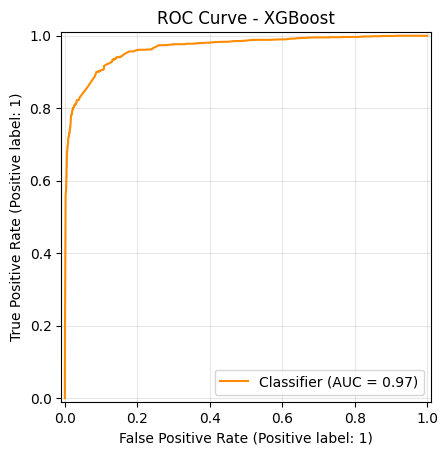

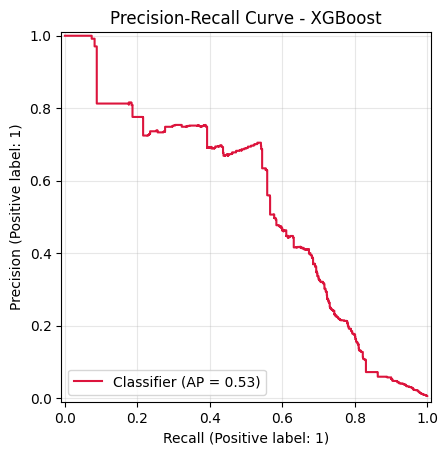

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay

# Predicted probabilities for XGBoost
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    color="darkorange"
)

plt.title("ROC Curve - XGBoost")
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    color="crimson"
)

plt.title("Precision-Recall Curve - XGBoost")
plt.grid(alpha=0.3)
plt.show()

Peformance Matrix Chart

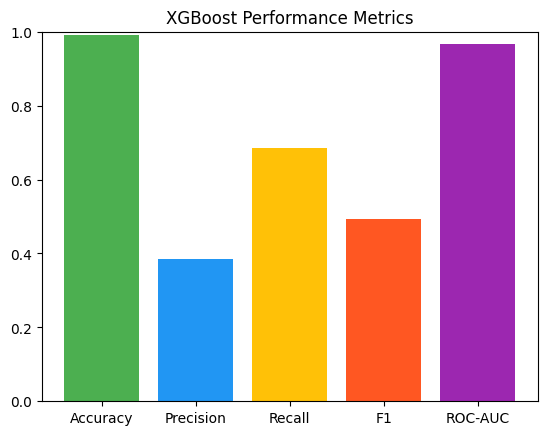

In [ ]:
plt.bar(
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    [
        accuracy_xgb,
        precision_xgb,
        recall_xgb,
        f1_xgb,
        roc_auc_xgb
    ],
    color=["#4CAF50", "#2196F3", "#FFC107", "#FF5722", "#9C27B0"]
)

plt.ylim(0, 1)
plt.title("XGBoost Performance Metrics")
plt.show()

Confusion Matrix

[[256196   1638]
 [   474   1027]]


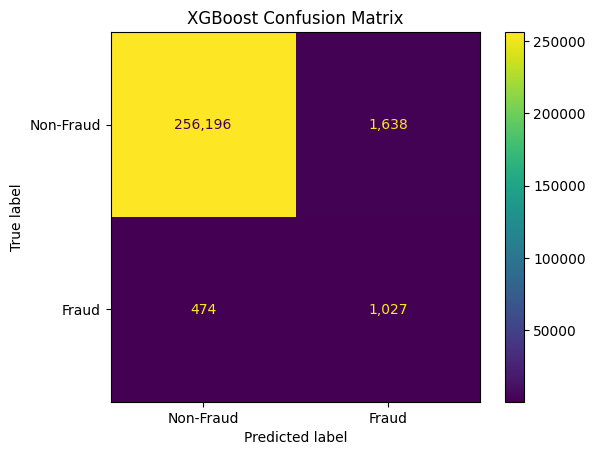

In [ ]:
# Calculate confusion matrix
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm_xgb)

# Display confusion matrix

display_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['Non-Fraud', 'Fraud']
)

display_xgb.plot(
    values_format=',d'
)

plt.title('XGBoost Confusion Matrix')
plt.show()

In [ ]:
# Extract confusion matrix values
tn, fp, fn, tp = cm_xgb.ravel()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

True Negatives:  256196
False Positives: 1638
False Negatives: 474
True Positives:  1027


K-Fold Cross Validation

In [ ]:
#Performing K-Fold on the dataset
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Applying SMOTE data within each fold
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42,
    n_estimators=100,
    max_depth=10))
])


scores = cross_val_score(pipeline, X_train_smote, y_train_smote, cv=skf, scoring='precision')
print(f'Cross-Validation Precision Scores: {scores}')
print(f'Mean Precision: {scores.mean():.2f}')




Cross-Validation Precision Scores: [0.95081527 0.95224342 0.9508596  0.95452164 0.94827613]
Mean Precision: 0.95


#Feature Importance Analysis and SHAP

XG Boost

      Feature  Importance
69  amt_bin_3    0.425411
68  amt_bin_2    0.226748
70  amt_bin_4    0.125707
67  amt_bin_1    0.048760
64   hour_cos    0.041717
65   is_night    0.033773
66  amt_bin_0    0.023484
1    category    0.021147
63   hour_sin    0.018820
59       hour    0.008961
46   state_PA    0.006962
5         job    0.004874
6         age    0.004274
3        city    0.004093
16   state_DE    0.003153


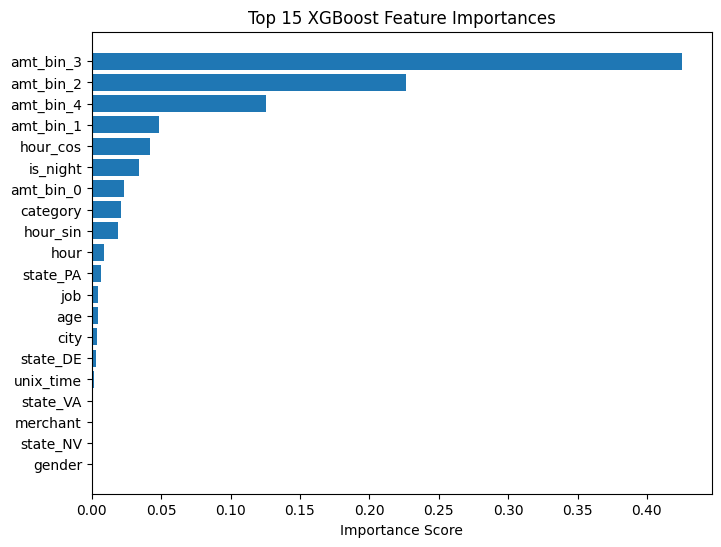

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importance_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': best_xgb.feature_importances_
})

# Sort
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top features
print(importance_df.head(15))

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    importance_df['Feature'].head(20)[::-1],
    importance_df['Importance'].head(20)[::-1]
)
plt.xlabel("Importance Score")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

In [ ]:
!pip install shap -q

In [ ]:
import shap

#Create SHAP explainer

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

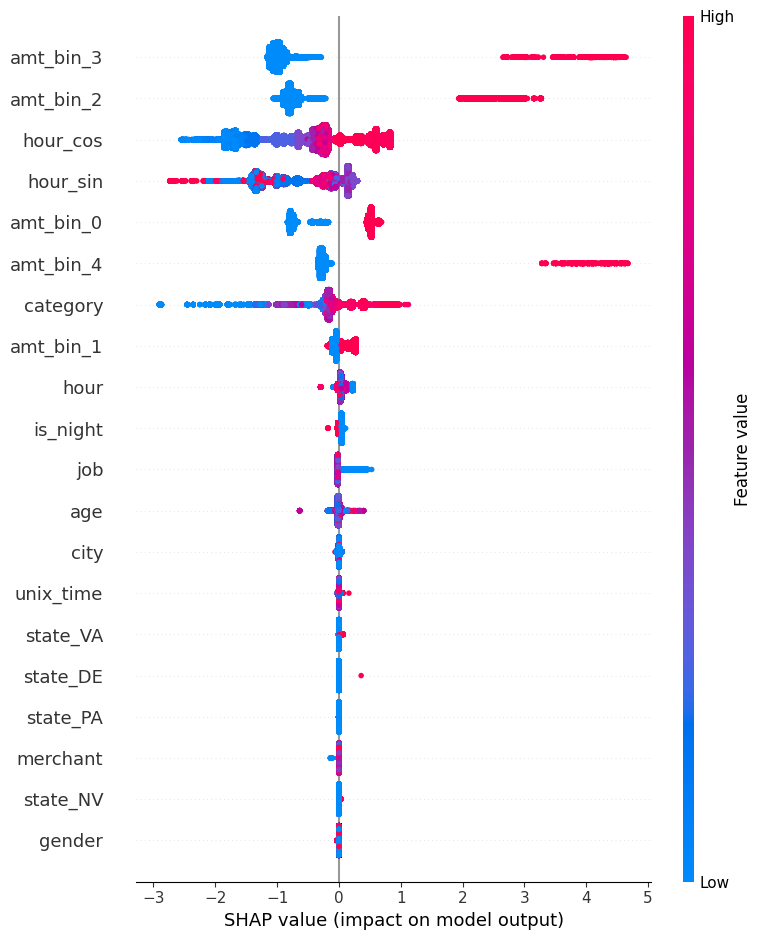

In [ ]:
#Plotting the SHAP values
shap.summary_plot(
    shap_values,
    X_test
)

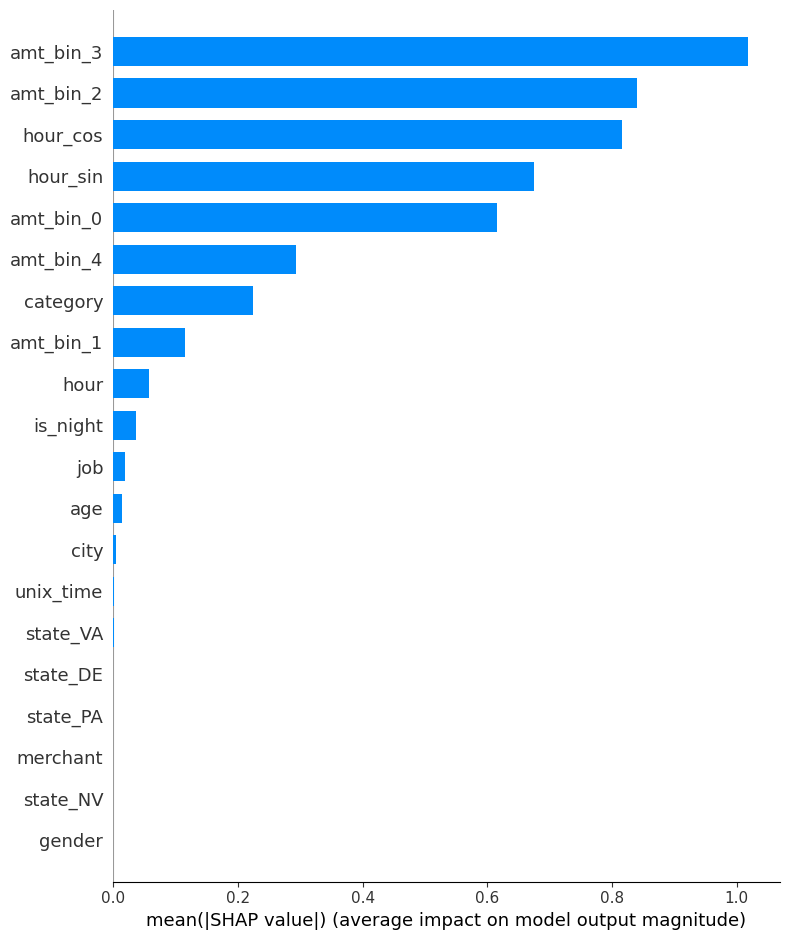

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

Explaining a prediction from Dataset

In [ ]:
fraud_index = y_test[y_test == 1].index[0]

row_position = X_test.index.get_loc(fraud_index)

In [ ]:
actual = y_test.loc[fraud_index]
prediction = best_xgb.predict(X_test.iloc[[row_position]])[0]

print("Actual:", actual)
print("Predicted:", prediction)

Actual: 1
Predicted: 0


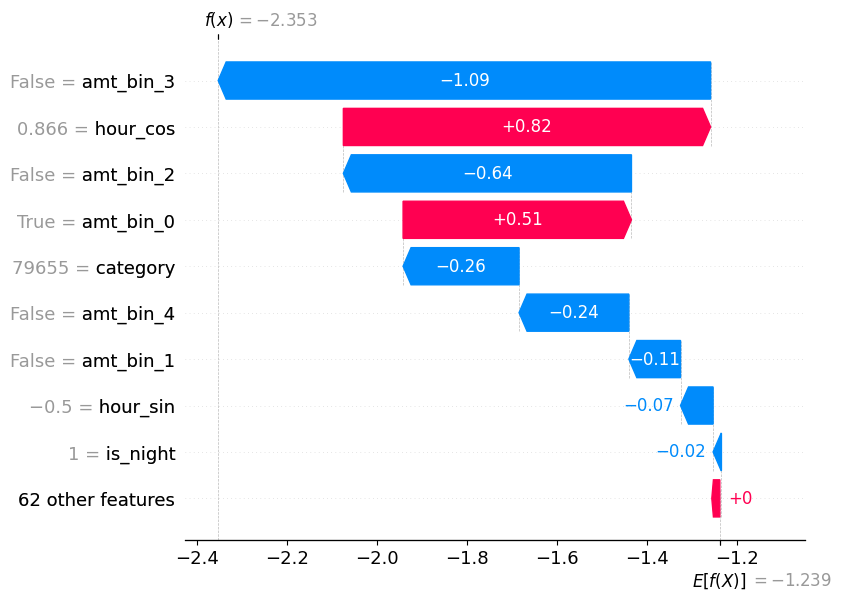

In [ ]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[row_position],
        base_values=explainer.expected_value,
        data=X_test.iloc[row_position],
        feature_names=X_test.columns
    )
)

#**Training Best XG Boost Model**

In [ ]:
top_15_features = [
    'amt_vs_avg',
    'amt_bin_3',
    'amt_bin_2',
    'card_avg_amt',
    'hour_cos',
    'amt_bin_4',
    'amt_bin_0',
    'hour_sin',
    'amt_bin_1',
    'trans_count_24h',
    'category',
    'secs_since_last',
    'is_night',
    'age',
    'hour'
]

In [ ]:
X_train_top15 = X_train_smote[top_15_features]
X_test_top15 = X_test[top_15_features]

xgb_top15 = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

xgb_top15.fit(X_train_top15, y_train_smote)

# y_pred_top15 = xgb_top15.predict(X_test_top15)
# y_prob_top15 = xgb_top15.predict_proba(X_test_top15)[:, 1]

# Get fraud probabilities
y_prob_top15 = xgb_top15.predict_proba(X_test_top15)[:, 1]

# Apply custom threshold
threshold = 0.65
y_pred_top15 = (y_prob_top15 >= threshold).astype(int)


KeyError: "['amt_vs_avg', 'card_avg_amt', 'trans_count_24h', 'secs_since_last'] not in index"

Evaluation Metrics

In [ ]:
# Calculate metrics
accuracy_top15 = accuracy_score(y_test, y_pred_top15)
precision_top15 = precision_score(y_test, y_pred_top15, zero_division=0)
recall_top15 = recall_score(y_test, y_pred_top15, zero_division=0)
f1_top15 = f1_score(y_test, y_pred_top15, zero_division=0)
roc_auc_top15 = roc_auc_score(y_test, y_prob_top15)

# Print results
print("="*45)
print("Top-15 Feature XGBoost Evaluation")
print("="*45)
print(f"Accuracy : {accuracy_top15:.4f}")
print(f"Precision: {precision_top15:.4f}")
print(f"Recall   : {recall_top15:.4f}")
print(f"F1 Score : {f1_top15:.4f}")
print(f"ROC-AUC  : {roc_auc_top15:.4f}")

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_top15,
    target_names=["Non-Fraud", "Fraud"],
    zero_division=0
))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

print(f"{'Threshold':<10}{'Precision':<12}{'Recall':<10}{'F1':<10}")

for t in thresholds:
    preds = (y_prob_top15 >= t).astype(int)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"{t:<10.2f}{precision:<12.4f}{recall:<10.4f}{f1:<10.4f}")

Performance Metrics Bar Chart

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    [
        accuracy_top15,
        precision_top15,
        recall_top15,
        f1_top15,
        roc_auc_top15
    ],
    color=["#4CAF50", "#2196F3", "#FFC107", "#FF5722", "#9C27B0"]
)

plt.ylim(0,1)
plt.title("Top-15 Feature XGBoost Performance")
plt.show()

Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_top15)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
).plot(values_format=',d')

plt.title("Top-15 Feature XGBoost Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

ROC Curve

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_top15,
    color="darkorange"
)

plt.title("ROC Curve - Top-15 XGBoost")
plt.grid(alpha=0.3)
plt.show()

Precision-Recall Curve

In [ ]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_top15,
    color="crimson"
)

plt.title("Precision-Recall Curve - Top-15 XGBoost")
plt.grid(alpha=0.3)
plt.show()

#**Saving the Best Model**

In [ ]:
import xgboost

print(xgboost.__version__)

In [ ]:
# Save actual XGBoost model
xgb_top15.save_model("best15_xgb2.json")

# Save feature order separately
model_info = {
    "features": xgb_top15.get_booster().feature_names
}

joblib.dump(model_info, "model_info.pkl")

In [ ]:
import joblib
from xgboost import XGBClassifier

# Load saved model
test_model = XGBClassifier()
test_model.load_model("best15_xgb2.json")

# Load saved feature order
model_info = joblib.load("model_info.pkl")
features = model_info["features"]

# Pick one known fraud row
fraud_index = y_test[y_test == 1].index[45]

fraud_row = X_test.loc[[fraud_index], features]
actual = int(y_test.loc[fraud_index])

# Predict
fraud_probability = float(
    test_model.predict_proba(fraud_row)[0, 1]
)

threshold = 0.80
prediction = int(
    fraud_probability >= threshold
)

print("Actual:", actual)
print("Fraud probability:", fraud_probability)
print("Predicted:", prediction)

..deploy to streamlit